In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import geopandas as gpd

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Kangxiwa Glacier coordinates:
kang_lat = 38.28
kang_lon = 75.28

In [4]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [5]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

### Load MAR dataset

In [7]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [8]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve le glacier Abramov

# distance sur grille
dist = np.sqrt((ds_lat - kang_lat)**2 + (ds_lon - kang_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le glacier Kangxiwa")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())
print("%ICE :", ds_ICE[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le glacier Kangxiwa
Indice Y : 22
Indice X : 84
Latitude : 38.25883865356445
Longitude : 75.26628875732422
Altitude : 4862.86279296875
%ICE : 15.15151596069336


In [9]:
dist = np.sqrt((ds_lat - kang_lat)**2 + (ds_lon - kang_lon)**2)
idx_1d = dist.argmin().item()
iY, iX = np.unravel_index(idx_1d, dist.shape)

iX_max= iX-1
iY_max = iY-1

print("Caratéristique de la maille MAR voisine du glacier Kangxiwa avec une cible sur le Zmed (RGI) du glacier")
print("Indice Y :", iY_max)
print("Indice X :", iX_max)
print("Latitude :", ds_lat[iY_max, iX_max].item())
print("Longitude :", ds_lon[iY_max, iX_max].item())
print("Altitude :", ds_SH[iY_max, iX_max].item())
print("Ice% :", ds_ICE[iY_max, iX_max].item())

Caratéristique de la maille MAR voisine du glacier Kangxiwa avec une cible sur le Zmed (RGI) du glacier
Indice Y : 21
Indice X : 83
Latitude : 38.19794464111328
Longitude : 75.18368530273438
Altitude : 5127.9013671875
Ice% : 42.42424392700195


/tmp/ipykernel_2607300/3323098067.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


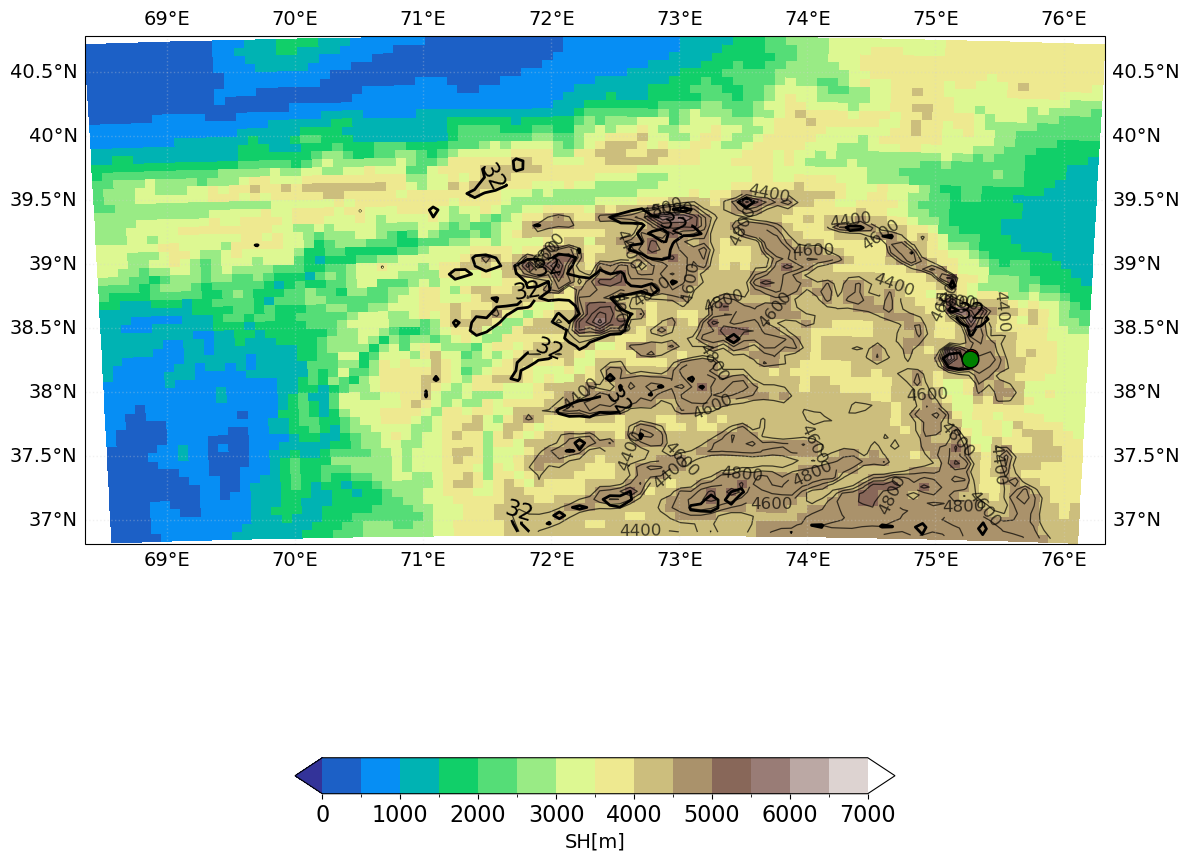

In [10]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Kangxiwa Glacier: red dot
ax.plot(kang_lon, kang_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_2607300/3317741047.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


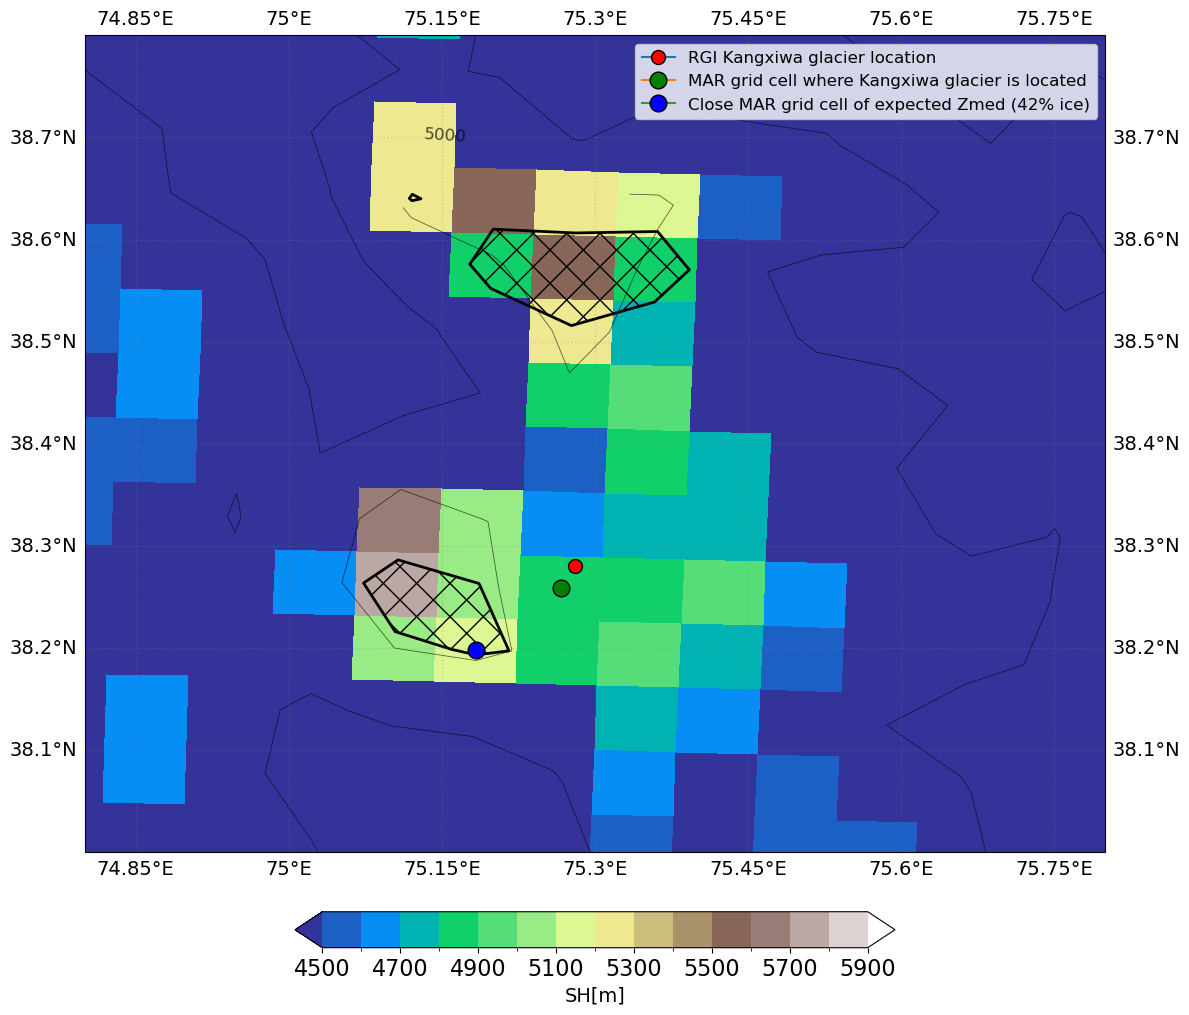

In [11]:
ice_level=40# % of ice on grid cell

clevs=np.arange(4500,6000,100)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Latitude : 39.67844009399414
# Longitude : 71.48213958740234
ax.set_extent([74.8, 75.8, 38, 38.8], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Kangxiwa Glacier : red dot
ax.plot(kang_lon, kang_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        label='RGI Kangxiwa glacier location',
        transform=ccrs.PlateCarree())

# point de grille ou se trouve Kangxiwa 
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        label='MAR grid cell where Kangxiwa glacier is located',
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())


# Highest grid cell close from Kangxiwa :
ax.plot(ds_lon[iY_max, iX_max], ds_lat[iY_max, iX_max],
        marker='o', markersize=12,
        label='Close MAR grid cell of expected Zmed (42% ice)',       
        markeredgecolor='black', markerfacecolor='blue',
        transform=ccrs.PlateCarree())

ax.legend(loc="upper right", fontsize=12)
plt.show()

### MAR datasets

# A ajouter ici : ds_SW mon mean


In [12]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [80]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [70]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [81]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [13]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [82]:
variable='SW' 
# Surface Water

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [83]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [84]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [85]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

## Sorties de MAR au point de Grille Kangxiwa Glacier

#### Temperature

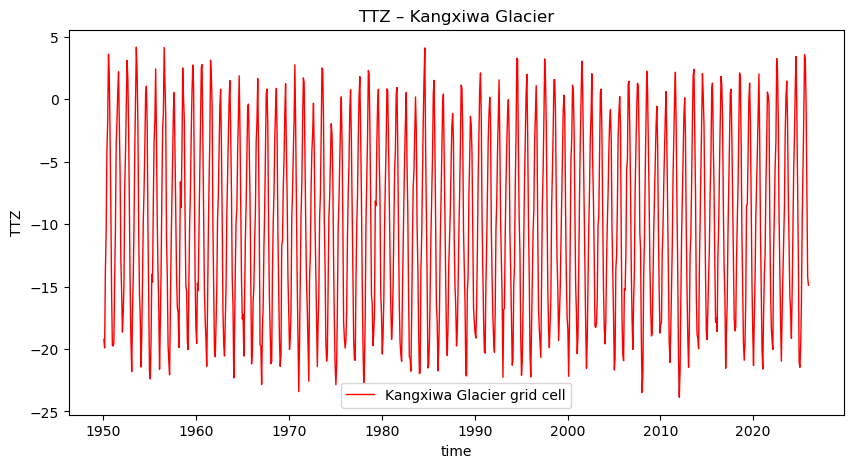

In [14]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_abra =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_abra.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("TTZ – Kangxiwa Glacier")
plt.ylabel("TTZ")
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


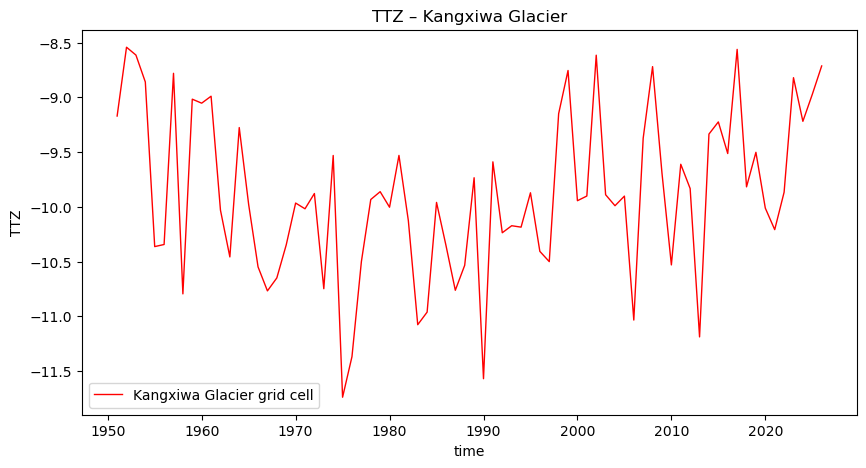

In [15]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_abra =  ds_TTZ.isel(Y=iY, X=iX).resample(time="1Y").mean()
ds_TTZ_abra.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("TTZ – Kangxiwa Glacier")
plt.ylabel("TTZ")
plt.show()

#### Precipitation

In [ ]:
# SF at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_SF_abra =  ds_SF.isel(Y=iY, X=iX).resample(time="1Y").sum()
ds_SF_abra.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("SF – Kangxiwa Glacier")
plt.ylabel("SF")
plt.show()

#### SMB

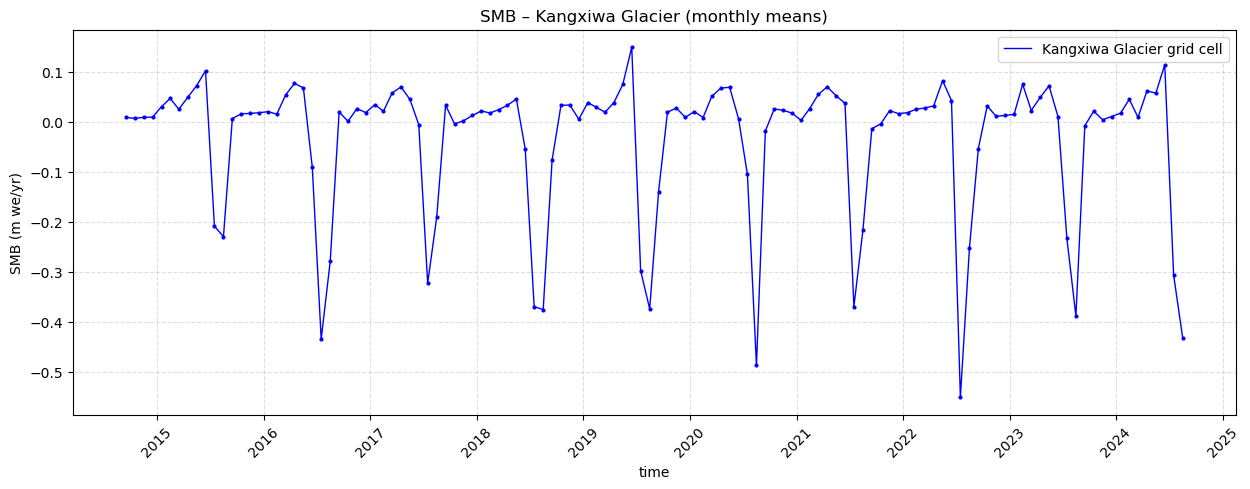

In [17]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Kangxiwa
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2014-09-01", "2024-08-31"))/1000

ds_SMB_kang.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="blue")
 
plt.plot(ds_SMB_kang.time,
         ds_SMB_kang,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Kangxiwa Glacier (monthly means)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

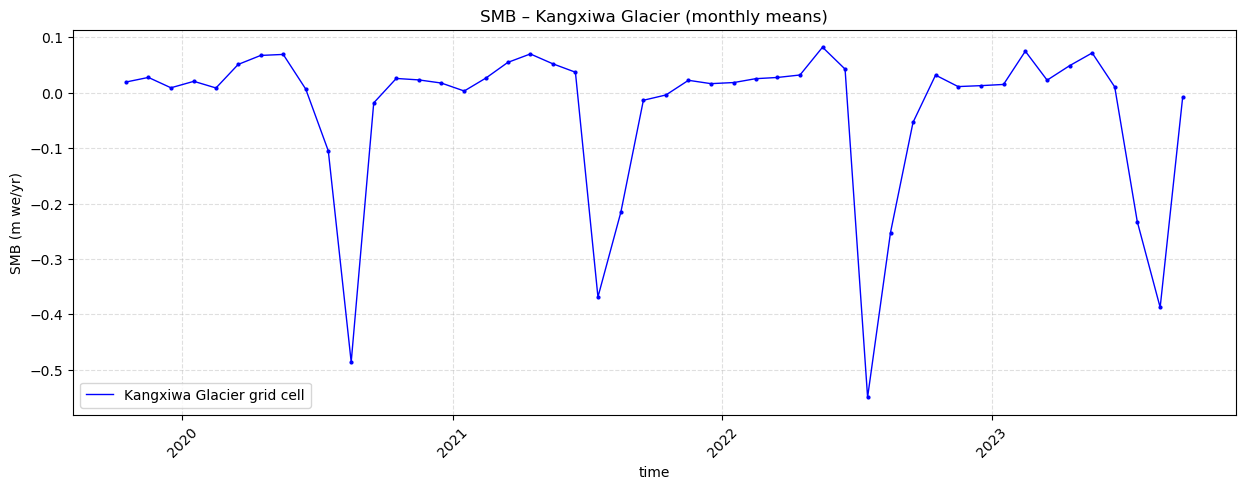

In [44]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Kangxiwa
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2019-10-01", "2023-09-30"))/1000

ds_SMB_kang.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_kang.time,
         ds_SMB_kang,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Kangxiwa Glacier (monthly means)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

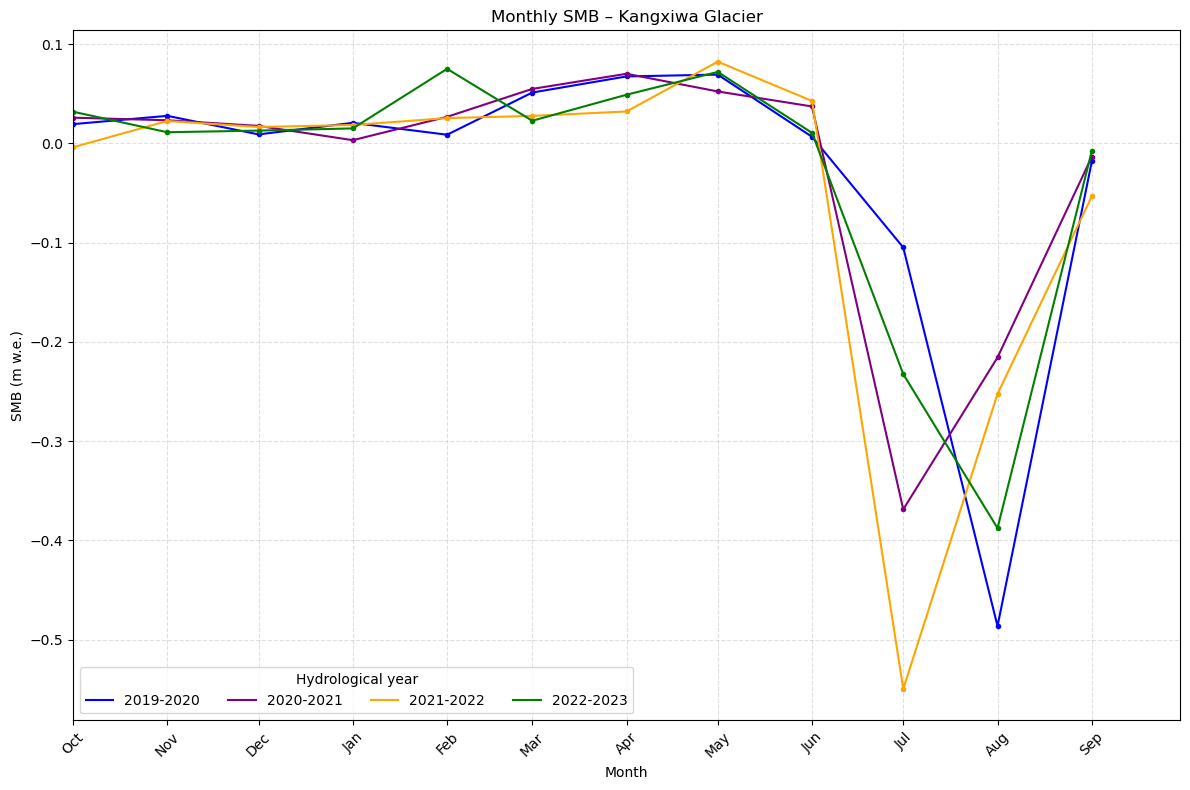

In [77]:
ds_SMB_kang = (
    ds_SMB
    .isel(Y=iY, X=iX)
    .sel(time=slice("2019-10-01", "2023-09-30"))
    / 1000
)

plt.figure(figsize=(12, 8))

colors = ["blue", "purple", "orange", "green"]

for i, year in enumerate(range(2019, 2023)):

    start = f"{year}-10-01"
    end   = f"{year+1}-09-30"

    # Sélection de l'année hydrologique
    ds_year = ds_SMB_kang.sel(time=slice(start, end))

    # Recaler les dates sur une année fictive :
    # Oct 2019 -> Oct 2000
    # Nov 2019 -> Nov 2000
    # ...
    # Sep 2020 -> Sep 2001
    new_time = [
        pd.Timestamp("2000-10-01") + pd.DateOffset(months=j)
        for j in range(len(ds_year.time))
    ]

    ds_year = ds_year.assign_coords(time=new_time)

    # Tracé de la ligne
    ds_year.plot(
        label=f"{year}-{year+1}",
        linewidth=1.5,
        color=colors[i]
    )

    # Points
    plt.plot(
        ds_year.time,
        ds_year,
        'o',
        color=colors[i],
        markersize=3
    )

# Axe X : 1er octobre -> 30 septembre
ax = plt.gca()

ax.set_xlim(
    pd.Timestamp("2000-10-01"),
    pd.Timestamp("2001-09-30")
)

# Afficher les mois
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("SMB (m w.e.)")
plt.title("Monthly SMB – Kangxiwa Glacier")

plt.legend(title="Hydrological year", ncol=4)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

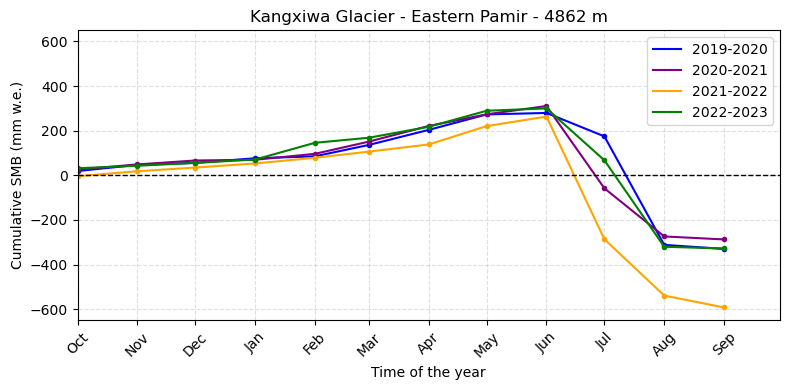

In [79]:
ds_SMB_sel = (
    ds_SMB
    .isel(Y=iY, X=iX)
    .sel(time=slice("2019-10-01", "2023-09-30"))
    / 1000
)

ds_SMB_sel= ds_SMB_sel*1000

plt.figure(figsize=(8, 4))

# Couleurs pour les 4 années hydrologiques
colors = ["blue", "purple", "orange", "green"]

# Années hydrologiques
for i, year in enumerate(range(2019, 2023)):

    start = f"{year}-10-01"
    end = f"{year+1}-09-30"

    # Sélection de l'année hydrologique
    ds_year = ds_SMB_sel.sel(time=slice(start, end))

    # Cumul au cours de l'année hydrologique
    ds_year = ds_year.cumsum(dim="time")

    # Recaler les dates sur une année fictive
    new_time = [
        pd.Timestamp("2000-10-01") + pd.DateOffset(months=j)
        for j in range(len(ds_year.time))
    ]

    ds_year = ds_year.assign_coords(time=new_time)

    # Courbe cumulée
    ds_year.plot(
        label=f"{year}-{year+1}",
        linewidth=1.5,
        color=colors[i]
    )

    # Points
    plt.plot(
        ds_year.time,
        ds_year,
        'o',
        color=colors[i],
        markersize=3
    )

# Axe X : 1er octobre → 30 septembre
ax = plt.gca()

ax.set_xlim(
    pd.Timestamp("2000-10-01"),
    pd.Timestamp("2001-09-30")
)

# Affichage des mois
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xticks(rotation=45)

plt.xlabel("Time of the year")
plt.ylabel("Cumulative SMB (mm w.e.)")
plt.title("Kangxiwa Glacier - Eastern Pamir - 4862 m")

ax.set_ylim(-650, 650)
ax = plt.gca()

# Ligne de référence à SMB cumulé = 0
ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

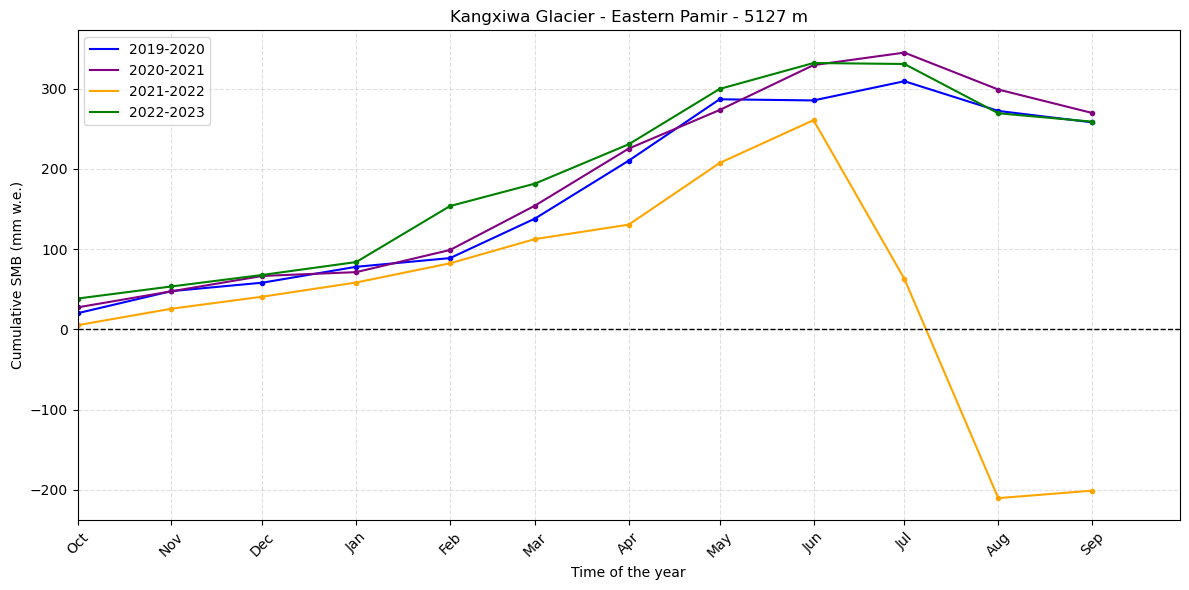

In [75]:
ds_SMB_sel = (
    ds_SMB
    .isel(Y=iY_max, X=iX_max)
    .sel(time=slice("2019-10-01", "2023-09-30"))
    / 1000
)

ds_SMB_sel= ds_SMB_sel*1000

plt.figure(figsize=(12, 6))

# Couleurs pour les 4 années hydrologiques
colors = ["blue", "purple", "orange", "green"]

# Années hydrologiques
for i, year in enumerate(range(2019, 2023)):

    start = f"{year}-10-01"
    end = f"{year+1}-09-30"

    # Sélection de l'année hydrologique
    ds_year = ds_SMB_sel.sel(time=slice(start, end))

    # Cumul au cours de l'année hydrologique
    ds_year = ds_year.cumsum(dim="time")

    # Recaler les dates sur une année fictive
    new_time = [
        pd.Timestamp("2000-10-01") + pd.DateOffset(months=j)
        for j in range(len(ds_year.time))
    ]

    ds_year = ds_year.assign_coords(time=new_time)

    # Courbe cumulée
    ds_year.plot(
        label=f"{year}-{year+1}",
        linewidth=1.5,
        color=colors[i]
    )

    # Points
    plt.plot(
        ds_year.time,
        ds_year,
        'o',
        color=colors[i],
        markersize=3
    )

# Axe X : 1er octobre → 30 septembre
ax = plt.gca()

ax.set_xlim(
    pd.Timestamp("2000-10-01"),
    pd.Timestamp("2001-09-30")
)

# Affichage des mois
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xticks(rotation=45)

plt.xlabel("Time of the year")
plt.ylabel("Cumulative SMB (mm w.e.)")
plt.title("Kangxiwa Glacier - Eastern Pamir - 5127 m")

ax = plt.gca()

# Ligne de référence à SMB cumulé = 0
ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


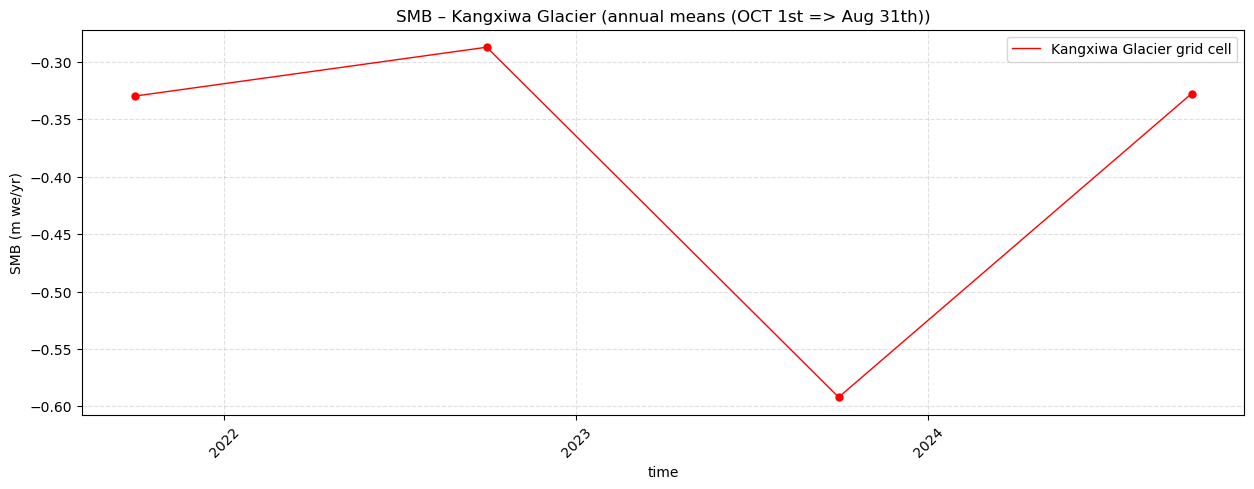

In [43]:
#SMB Annual (from Sept 1 to Aug 31)


plt.figure(figsize=(15,5))

# Point précis Kangxiwa
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_kang_annual = ds_SMB_kang.resample(time="A-SEP").sum().sel(time=slice("2019-10-01", "2023-09-30"))/1000

# "le groupe septembre 1967 → août 1968 est étiqueté par 1967-09-01." => resample donne le début de l'année hydro en time
# Ajouter une année 
ds_SMB_kang_annual["time"] = (
    ds_SMB_kang_annual.time.to_index() + pd.DateOffset(years=1)
)


ds_SMB_kang_annual.plot(label="Kangxiwa Glacier grid cell", linewidth=1, color="red")

plt.plot(ds_SMB_kang_annual.time,
         ds_SMB_kang_annual,
         'o', color='red', markersize=5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Kangxiwa Glacier (annual means (OCT 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

#### SMB moyen

In [22]:
# Point précis Kangxiwa
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX)

# "le groupe septembre 1967 → août 1968 est étiqueté par 1967-09-01." => resample donne le début de l'année hydro en time
# Ajouter une année 
# "resample(time="A-SEP")" : ca se termine au 30/09

ds_SMB_kang_annual = ds_SMB_kang.resample(time="A-SEP").sum().sel(time=slice("2019-10-01", "2023-09-30"))/1000
print(f"SMB moyen de 2019/20 à 2022/23: {ds_SMB_kang_annual.values}")

SMB moyen de 2019/20 à 2022/23: [-0.3297617  -0.2871875  -0.59207034 -0.32764062]


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


In [ ]:
# Point précis Abramov
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX)

# selection de la période rapportée par Kronenberg :
# « The mass balance of Abramov Glacier is predominantly negative for the years from 1968/1969 to 2019/2020, with a mean value of −0.27 m w.e. a−1 » 
ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1968-09-01", "2014-08-31"))/1000

ds_SMB_abra_annual_mean = ds_SMB_abra_annual.mean(dim="time")
print(f"Moyenne sur la période sélectionnée : {ds_SMB_abra_annual_mean.values}")

#### Cumul du SMB

In [ ]:
# =========================
# SMB annuel (Sep → Aug)
# =========================

ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX)

ds_SMB_abra_annual = (
    ds_SMB_abra
    .resample(time="AS-SEP")
    .sum()
    .sel(time=slice("1980-09-01", "2024-08-31"))
    / 1000  # m w.e.
)

# "le groupe septembre 1967 → août 1968 est étiqueté par 1967-09-01." => resample donne le début de l'année hydro en time
# Ajouter une année 
ds_SMB_abra_annual["time"] = (
    ds_SMB_abra_annual.time.to_index() + pd.DateOffset(years=1)
)


# =========================
# CUMUL SMB
# =========================

ds_SMB_cum = ds_SMB_abra_annual.cumsum(dim="time")

# =========================
# PLOT
# =========================

plt.figure(figsize=(15,5))

plt.plot(
    ds_SMB_cum.time,
    ds_SMB_cum,
    '-',
    color='black',
    linewidth=2,
    label="Cumulative SMB"
)

# =========================
# AXES
# =========================

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title("SMB – Abramov Glacier (cumulative, Sep→Aug)")
plt.ylabel("SMB (m w.e.)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

## Composantes du SMB

In [69]:
# SMB = SF - ME + RZ - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU,
    "SW": ds_SW
}

NameError: name 'ds_SF' is not defined

In [ ]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SU", "SW"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

# Couleurs pour les histos
colors = {
    "SF": "#a6cee3",   # bleu clair 
    "ME": "#fb9a99",   # rouge clair
    "RZ": "#cab2d6",   # violet clair
    "SU": "#fdbf6f",   # orange clair
    "SW": "#1f78b4",   # bleu foncé 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("mass flux (mm w.e)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : Abramov Glacier grid cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()


ax.legend(ncol=2)

plt.show()

## Observation of SMB at Kangxiwa

### RGI database

In [23]:
rgi_v6 = gpd.read_file(
    "/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/RGI/v6/13_rgi60_CentralAsia.shp"
)
print(rgi_v6.columns)


Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'geometry'],
      dtype='object')


In [24]:
kang_rgi = rgi_v6[rgi_v6['RGIId'] == 'RGI60-13.41822']

In [25]:
print(kang_rgi["Zmin"], kang_rgi["Zmed"], kang_rgi["Zmax"], kang_rgi["Area"])

41819    4962
Name: Zmin, dtype: int32 41819    5153
Name: Zmed, dtype: int32 41819    5359
Name: Zmax, dtype: int32 41819    2.593
Name: Area, dtype: float64


### Xie et al. 2026

In [40]:
obs_kang = {
    "year": ["2019/2020", "2020/2021", "2021/2022", "2022/2023"],
    "SMB": [0.045, -0.121, -0.654, -0.337]
}

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


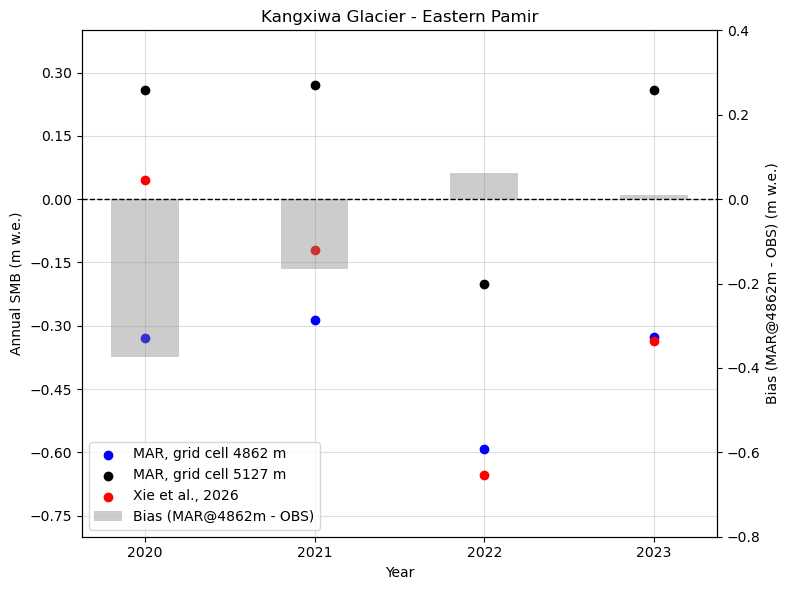

In [68]:
# Point de grille contenant le glacier Kangxiwa
ds_SMB_kang = ds_SMB.isel(Y=iY, X=iX)

# Point de grille voisin à ZMed proche de l'altitude moyenne réelle du glacier
ds_SMB_kang_max = ds_SMB.isel(Y=iY_max, X=iX_max)


ds_SMB_kang_annual = (
    ds_SMB_kang
    .resample(time="A-SEP")
    .sum()
    .sel(time=slice("2019-10-01", "2023-09-30"))
    / 1000
)

ds_SMB_kang_annual_max = (
    ds_SMB_kang_max
    .resample(time="A-SEP")
    .sum()
    .sel(time=slice("2019-10-01", "2023-09-30"))
    / 1000
)


years = pd.to_datetime(ds_SMB_kang_annual.time.values).year

smb_values = ds_SMB_kang_annual.values
smb_values_max = ds_SMB_kang_annual_max.values


df_obs = pd.DataFrame(obs_kang)

obs_values = df_obs["SMB"].values

bias = smb_values - obs_values


fig, ax1 = plt.subplots(figsize=(8, 6))


ax1.scatter(
    years,
    smb_values,
    color='blue',
    label='MAR, grid cell 4862 m',
    zorder=5
)

ax1.scatter(
    years,
    smb_values_max,
    color='black',
    label='MAR, grid cell 5127 m',
    zorder=5
)

ax1.scatter(
    years,
    obs_values,
    color='red',
    label='Xie et al., 2026',
    zorder=5
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Annual SMB (m w.e.)")
ax1.set_title("Kangxiwa Glacier - Eastern Pamir")

ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))


ax1.grid(True, alpha=0.4)


ax2 = ax1.twinx()

ax2.bar(
    years,
    bias,
    width=0.4,
    color='gray',
    alpha=0.4,
    label='Bias (MAR@4862m - OBS)',
    zorder=2
)

ax2.set_ylabel("Bias (MAR@4862m - OBS) (m w.e.)")

# Ligne zéro du biais
ax2.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

ax1.set_ylim(-0.8, 0.4)
ax2.set_ylim(-0.8, 0.4)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

In [71]:
1+1

2